# 분류 실습 — 타이타닉 생존 여부 예측

이번 실습은 **코드를 직접 작성하는 대신, 주어진 코드를 실행하고 결과를 해석하는 방식**으로 진행합니다.

모든 코드 셀은 그대로 실행하면 동작합니다. 위에서부터 차례대로 실행하면서,
**🤔 질문 셀에 여러분의 답을 마크다운으로 직접 작성**해주세요.

**목표**: 승객 정보가 주어졌을 때 생존 여부를 예측하는 **이진 분류** 모델을 만들고 평가하기

---



## 0. 데이터 준비 (그냥 실행하고 넘어가세요)

전처리는 지난 시간에 다뤘으므로 여기서는 **코드만 실행**합니다.
결측치를 채우고, 범주형을 숫자로 바꾸고, 나이·요금을 구간화하는 과정입니다.

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\dudvn\Downloads\titanic (1).csv")

# 이름에서 호칭 추출 → Age 결측치를 호칭별 평균으로 채우기
df['Initial'] = ""
for index, row in df.iterrows():
    df.loc[index, 'Initial'] = row['Name'].split(',')[1].split('.')[0].strip()

df['Initial'] = df['Initial'].replace(
    ['Mlle', 'Mme', 'Ms', 'Dr', 'Major', 'Lady', 'Countess', 'Jonkheer', 'Col',
     'Rev', 'Capt', 'Sir', 'Don', 'the Countess'],
    ['Miss', 'Miss', 'Miss', 'Mr', 'Mr', 'Mrs', 'Mrs', 'Other', 'Other',
     'Other', 'Mr', 'Mr', 'Mr', 'Other'])

for ini, age in [('Mr', 33), ('Mrs', 36), ('Master', 5), ('Miss', 22), ('Other', 46)]:
    df.loc[(df.Age.isnull()) & (df.Initial == ini), 'Age'] = age

# 불필요한 컬럼 정리
df.dropna(subset=['Embarked'], inplace=True)
df.drop(['Cabin', 'Name', 'PassengerId', 'Ticket'], axis=1, inplace=True)
df_org = df.copy()

# 피처 엔지니어링
df['Sex']      = df['Sex'].map({'male': 0, 'female': 1})
df['Age']      = (df['Age'] // 10).astype(int)          # 나이 → 10년 단위 구간
df['Fare']     = pd.qcut(df['Fare'], q=9, labels=range(9))  # 요금 → 9분위 구간
df['Embarked'] = df['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})
df['Initial']  = df['Initial'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Other': 4})
df['Relatives'] = df["SibSp"] + df["Parch"]

print("전처리 완료:", df.shape, " 결측치:", df.isnull().sum().sum())
df.head()

전처리 완료: (889, 10)  결측치: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Initial,Relatives
0,0,3,0,2,1,0,0,1,0,1
1,1,1,1,3,1,0,7,2,2,1
2,1,3,1,2,0,0,2,1,1,0
3,1,1,1,3,1,0,7,1,2,1
4,0,3,0,3,0,0,2,1,0,0


---
## 1. 분류 문제 정의하기

분류 모델을 만들기 전에 **무엇을 맞힐 것인지(target)** 와 **무엇을 보고 맞힐 것인지(feature)** 를 정합니다.

In [5]:
X = df.drop('Survived', axis=1)   # feature (독립변수)
y = df['Survived']                # target  (종속변수)

print("feature:", list(X.columns))
print()
print("[ y 분포 ]")
print(y.value_counts())
print()
print("사망(0) 비율: %.4f" % (y == 0).mean())

feature: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Initial', 'Relatives']

[ y 분포 ]
Survived
0    549
1    340
Name: count, dtype: int64

사망(0) 비율: 0.6175


### 🤔 Q1. 기준선(baseline) 잡기  

사망 549명, 생존 340명입니다.

1. 모델을 전혀 만들지 않고 **"모든 승객은 사망했다"고만 찍는다면** 정확도가 몇 %일까요? 계산식과 값을 적어주세요.
2. 이 숫자를 **모델을 만들기 전에 미리 계산해두는 것**이 왜 중요한지 설명해주세요.
3. 만약 우리 모델의 정확도가 60%로 나왔다면, 이 모델을 어떻게 평가해야 할까요? (1번에서 구한 숫자와 비교해서 답해주세요)

**답:**



---
## 2. 훈련 세트와 테스트 세트 나누기

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("train:", len(X_train), " test:", len(X_test))
print()
print("[ 생존 비율 비교 ]")
print("전체   : %.4f" % (y == 1).mean())
print("y_train: %.4f" % (y_train == 1).mean())
print("y_test : %.4f" % (y_test == 1).mean())

train: 711  test: 178

[ 생존 비율 비교 ]
전체   : 0.3825
y_train: 0.3812
y_test : 0.3876


### 🤔 Q2. 왜 나누고, random_state는 뭘까  

1. 데이터를 훈련용과 테스트용으로 나누는 이유는 무엇인가요? 전부 학습에 쓰면 더 좋은 모델이 나오지 않을까요?
2. `random_state=42`를 빼고 여러 번 실행하면 어떤 일이 생길까요? 그게 왜 문제가 되나요?
3. 세 생존 비율(0.3825 / 0.3812 / 0.3876)이 비슷하게 나왔습니다. 이렇게 비슷하게 나오는 것이 **항상 보장**될까요? 보장하려면 어떤 옵션을 써야 할까요?

**답:**



---
## 3. 스케일링 — 어떤 모델에 필요한가

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 스케일링 전/후 성능 비교
rows = []
for name, model in [('로지스틱 회귀', LogisticRegression()),
                    ('의사결정나무', DecisionTreeClassifier(random_state=42)),
                    ('SVM', SVC(random_state=42)),
                    ('kNN', KNeighborsClassifier())]:
    from sklearn.base import clone
    raw    = clone(model).fit(X_train, y_train).score(X_test, y_test)
    scaled = clone(model).fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
    rows.append({'모델': name, '스케일링 X': round(raw, 4),
                 '스케일링 O': round(scaled, 4), '차이': round(scaled - raw, 4)})

print("[ 스케일링 전 각 feature의 범위 ]")
print(X_train.agg(['min', 'max']).T)
print()
pd.DataFrame(rows).set_index('모델')

[ 스케일링 전 각 feature의 범위 ]
           min  max
Pclass       1    3
Sex          0    1
Age          0    8
SibSp        0    8
Parch        0    6
Fare         0    8
Embarked     1    3
Initial      0    4
Relatives    0   10



,스케일링 X,스케일링 O,차이
모델,,,
로지스틱 회귀,0.7809,0.7865,0.0056
의사결정나무,0.8090,0.8090,0.0000
SVM,0.8034,0.8034,0.0000
kNN,0.7472,0.7809,0.0337


### 🤔 Q3. 스케일링의 정체  

1. `X_train`에는 `fit_transform`을, `X_test`에는 `transform`만 씁니다. `fit`이 하는 일이 무엇이길래 이렇게 구분할까요? 테스트에도 `fit_transform`을 쓰면 구체적으로 무엇이 잘못되나요?
2. **의사결정나무**는 스케일링 전후 정확도가 소수점 넷째 자리까지 완전히 같습니다(0.8090 → 0.8090). 트리가 데이터를 어떻게 사용하는지 떠올려보고, 왜 값이 똑같은지 설명해주세요.


**답:**



---
## 4. 로지스틱 회귀 — 학습과 평가

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')
print()
print("정확도:", accuracy_score(y_test, y_pred))

True Negatives  (TN): 85
False Positives (FP): 24
False Negatives (FN): 14
True Positives  (TP): 55

정확도: 0.7865168539325843


### 🤔 Q4. 혼동 행렬 읽기  

`TN=85, FP=24, FN=14, TP=55` 입니다. (**Positive = 생존**)

1. **FN(False Negative)의 정의에 입각하여**, `FN = 14`가 어떤 승객 14명인지 설명해주세요.
   아래 빈칸을 채우는 형태로 답하면 됩니다.
   > "실제로는 `______`인데, 모델은 `______`라고 예측한 승객 14명"
2. 같은 방식으로 `FP = 24`도 설명해주세요.
3. TN/FP/FN/TP만으로 **정확도를 직접 계산**해보세요. 식과 값을 모두 적어주세요.
   > 정확도 = ( `__` + `__` ) / 178 = `____`
4. **정밀도(precision)** 와 **재현율(recall)** 도 직접 계산해주세요. 식과 값을 모두 적어주세요.
   > 💡 힌트: 두 지표는 분자는 같고 **분모(= 무엇을 모수로 삼는가)가 다릅니다.**
   > precision은 *모델이 생존이라고 예측한 사람들* 중에서, recall은 *실제 생존자* 중에서 따집니다.

**답:**



In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82       109
           1       0.70      0.80      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



In [10]:
# Q5 보조 자료 ─ 두 클래스의 "오답률"과, 모델이 만든 "예측 바구니"의 구성 비교
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("[ ① 실제 클래스별로 얼마나 틀렸나  → recall 의 뒷면 ]")
print(f"  실제 사망 {tn+fp:3d}명 중 {fp:2d}명 오답 → 오답률 {fp/(tn+fp):.3f}   (recall {tn/(tn+fp):.3f})")
print(f"  실제 생존 {fn+tp:3d}명 중 {fn:2d}명 오답 → 오답률 {fn/(fn+tp):.3f}   (recall {tp/(fn+tp):.3f})")
print()
print("[ ② 모델이 만든 '예측 바구니'의 크기와 구성 → precision ]")
print(f"  '사망'이라 예측한 바구니 {tn+fn:3d}명 = 정답 {tn:2d} + 오답 {fn:2d} → precision {tn/(tn+fn):.3f}")
print(f"  '생존'이라 예측한 바구니 {tp+fp:3d}명 = 정답 {tp:2d} + 오답 {fp:2d} → precision {tp/(tp+fp):.3f}")
print()
print("  ※ 사망 쪽 오답 24명이 통째로 '생존 바구니'(79명)로 흘러들어간 반면,")
print("     생존 쪽 오답 14명은 훨씬 큰 '사망 바구니'(99명)에 섞여 희석됩니다.")

[ ① 실제 클래스별로 얼마나 틀렸나  → recall 의 뒷면 ]
  실제 사망 109명 중 24명 오답 → 오답률 0.220   (recall 0.780)
  실제 생존  69명 중 14명 오답 → 오답률 0.203   (recall 0.797)

[ ② 모델이 만든 '예측 바구니'의 크기와 구성 → precision ]
  '사망'이라 예측한 바구니  99명 = 정답 85 + 오답 14 → precision 0.859
  '생존'이라 예측한 바구니  79명 = 정답 55 + 오답 24 → precision 0.696

  ※ 사망 쪽 오답 24명이 통째로 '생존 바구니'(79명)로 흘러들어간 반면,
     생존 쪽 오답 14명은 훨씬 큰 '사망 바구니'(99명)에 섞여 희석됩니다.


### 🤔 Q5. 분류 보고서 해석  

| | precision | recall | support |
|---|---|---|---|
| **0 (사망)** | 0.86 | 0.78 | 109명 |
| **1 (생존)** | 0.70 | 0.80 | 69명 |

1. 두 클래스를 비교하면 **recall은 거의 같은데(0.78 vs 0.80) precision만 크게 벌어집니다(0.86 vs 0.70).**
   - **(a)** recall이 두 클래스에서 비슷하다는 것은, 모델이 각 클래스를 얼마나 잡아냈다는 뜻인가요? 한 줄로 적어주세요.
   - **(b)** 그렇다면 precision의 차이는 어디서 왔을까요? **위 보조 자료 셀의 출력(오답의 개수와 예측 바구니의 크기)을 근거로** 설명해주세요.
2. 〔선택〕 `macro avg`(0.78)와 `weighted avg`(0.80)의 차이는 어디서 오나요? **계산식으로** 보여주세요.
3. 클래스가 심하게 불균형한 상황이라면 `macro avg`와 `weighted avg` 중 어느 쪽을 봐야 할까요? 이유와 함께 적어주세요.

**답:**



In [11]:
coef = pd.Series(lr_model.coef_[0], index=X.columns).sort_values(ascending=False)
print("[ 로지스틱 회귀 계수 ]  (양수 = 생존 확률 ↑)")
print(coef.round(3))

[ 로지스틱 회귀 계수 ]  (양수 = 생존 확률 ↑)
Initial      2.149
Sex          2.045
Fare         1.095
Embarked     0.614
Parch       -0.607
Pclass      -1.574
SibSp       -1.691
Relatives   -1.717
Age         -1.980
dtype: float64


### 🤔 Q6. 계수 해석하기  

로지스틱 회귀는 각 feature에 **가중치(계수)** 를 부여합니다. 양수면 생존 확률을 높이고, 음수면 낮춥니다.

1. `Sex`의 계수가 **+2.045**입니다. `Sex`는 male=0, female=1로 인코딩했었죠. 이 계수는 무엇을 말하고 있나요?
2. `Age`는 **-1.980**, `Pclass`는 **-1.574**입니다. 각각 무슨 뜻인지 설명해주세요.


**답:**


이렇게 **계수를 읽어서 해석할 수 있다는 점**이 로지스틱 회귀의 큰 장점입니다. 


---
## 5. 확률과 임계값 ⭐

`predict()`는 사실 **확률을 계산한 뒤 0.5를 기준으로 잘라주는 것**입니다.
그 0.5는 어디서 온 값일까요? 직접 바꿔봅시다.

In [12]:
proba = lr_model.predict_proba(X_test_scaled)[:, 1]   # 생존일 확률

print("앞 10명의 생존 확률:", proba[:10].round(3))
print()

rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred_t = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    rows.append({'임계값': t, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
                 '정확도':  round((tp + tn) / len(y_test), 3),
                 'recall':    round(tp / (tp + fn), 3),
                 'precision': round(tp / (tp + fp), 3)})

pd.DataFrame(rows).set_index('임계값')

앞 10명의 생존 확률: [0.091 0.894 0.674 0.184 0.925 0.08  0.224 0.103 0.94  0.946]



,TN,FP,FN,TP,정확도,recall,precision
임계값,,,,,,,
0.2,66,43,8,61,0.713,0.884,0.587
0.3,76,33,8,61,0.770,0.884,0.649
0.4,79,30,11,58,0.770,0.841,0.659
0.5,85,24,14,55,0.787,0.797,0.696
0.6,90,19,19,50,0.787,0.725,0.725
0.7,100,9,27,42,0.798,0.609,0.824
0.8,106,3,38,31,0.770,0.449,0.912


### 🤔 Q7. 임계값을 움직이면 무슨 일이 일어나는가  〔필수 · 14분〕

> ⭐ **이번 실습에서 가장 중요한 문제입니다.** 시간이 부족하면 다른 문항을 줄이고 여기에 집중하세요.

1. 임계값을 **0.5 → 0.2로 낮추면** FN과 FP는 각각 어떻게 변하나요? recall과 precision은요? 표에서 숫자를 읽어 적고, 왜 그렇게 변하는지 설명해주세요.
2. 임계값을 **0.8로 높이면** 어떻게 되나요? 마찬가지로 숫자와 이유를 적어주세요.

**답:**



---
## 6. 의사결정나무 — 복잡할수록 좋을까

max_depth  train 정확도  test 정확도  리프 개수
        1     0.7806    0.7978      2
        2     0.8228    0.8034      4
        3     0.8326    0.8034      8
        4     0.8439    0.8090     14
        5     0.8537    0.8146     22
        7     0.8819    0.8090     51
       10     0.9128    0.7978    113
     None     0.9226    0.8090    144


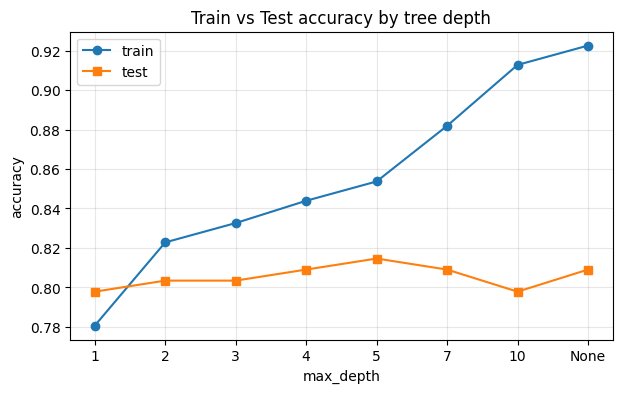

In [13]:
rows = []
for d in [1, 2, 3, 4, 5, 7, 10, None]:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train_scaled, y_train)
    rows.append({'max_depth': str(d),
                 'train 정확도': round(tree.score(X_train_scaled, y_train), 4),
                 'test 정확도':  round(tree.score(X_test_scaled,  y_test),  4),
                 '리프 개수': tree.get_n_leaves()})

depth_df = pd.DataFrame(rows)
print(depth_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(range(len(depth_df)), depth_df['train 정확도'], 'o-', label='train')
plt.plot(range(len(depth_df)), depth_df['test 정확도'],  's-', label='test')
plt.xticks(range(len(depth_df)), depth_df['max_depth'])
plt.xlabel('max_depth'); plt.ylabel('accuracy'); plt.legend(); plt.grid(alpha=.3)
plt.title('Train vs Test accuracy by tree depth')
plt.show()

### 🤔 Q8. 트리 깊이와 과적합  

1. `max_depth`가 깊어질수록 **train 정확도**는 어떻게 변하나요? **test 정확도**는요? 각각 표에서 숫자를 읽어 적어주세요.
2. 두 선의 간격이 벌어지는 현상을 뭐라고 부르나요? 왜 이런 일이 생기는지 트리가 데이터를 나누는 방식과 연결해 설명해주세요.
3. `max_depth=None`(제한 없음)일 때 리프가 **144개**이고 훈련 데이터는 **711개**입니다.
   > 👉 **리프 하나에 훈련 데이터가 평균 몇 개씩 들어있는지 계산**하고, 그 숫자가 이 모델에 대해 무엇을 말해주는지 설명해주세요.
4. 이 결과만 놓고 볼 때 어떤 깊이를 고르시겠어요? 근거를 들어 답해주세요.

**답:**



In [14]:
tree_model = DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train)

importance = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("[ 의사결정나무의 feature 중요도 ]")
print(importance.round(3))
print()
print("[ 참고: 로지스틱 회귀 계수의 절댓값 ]")
print(pd.Series(abs(lr_model.coef_[0]), index=X.columns).sort_values(ascending=False).round(3))

[ 의사결정나무의 feature 중요도 ]
Initial      0.408
Relatives    0.138
Age          0.119
Fare         0.118
Pclass       0.095
Embarked     0.060
Parch        0.031
SibSp        0.025
Sex          0.006
dtype: float64

[ 참고: 로지스틱 회귀 계수의 절댓값 ]
Initial      2.149
Sex          2.045
Age          1.980
Relatives    1.717
SibSp        1.691
Pclass       1.574
Fare         1.095
Embarked     0.614
Parch        0.607
dtype: float64


In [15]:
# Q9 보조 자료 ─ Initial(호칭)과 Sex(성별)는 정말 서로 다른 정보일까?
print("[ ① 호칭 × 성별 교차표 (전처리 전 원본 값) ]")
print(pd.crosstab(df_org['Initial'], df_org['Sex']))
print()
guess = df_org.groupby('Initial')['Sex'].transform(lambda s: s.mode()[0])
print("  → 호칭만 보고 성별을 맞히면 정확도: %.4f (%d/%d명)"
      % ((guess == df_org['Sex']).mean(), (guess == df_org['Sex']).sum(), len(df_org)))
print()

print("[ ② Initial을 아예 빼고 트리를 다시 학습하면? ]")
X2 = X.drop(columns=['Initial'])
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y, test_size=0.2, random_state=42)
sc2 = MinMaxScaler()
t2 = DecisionTreeClassifier(random_state=42).fit(sc2.fit_transform(X2_tr), y2_tr)
print(pd.Series(t2.feature_importances_, index=X2.columns).sort_values(ascending=False).round(3))
print("  → test 정확도: %.4f  (Initial 포함 모델은 0.8090)" % t2.score(sc2.transform(X2_te), y2_te))

[ ① 호칭 × 성별 교차표 (전처리 전 원본 값) ]
Sex      female  male
Initial              
Master        0    40
Miss        185     0
Mr            1   528
Mrs         125     0
Other         1     9

  → 호칭만 보고 성별을 맞히면 정확도: 0.9978 (887/889명)

[ ② Initial을 아예 빼고 트리를 다시 학습하면? ]
Sex          0.371
Age          0.188
Pclass       0.130
Fare         0.110
Relatives    0.094
Embarked     0.051
Parch        0.031
SibSp        0.025
dtype: float64
  → test 정확도: 0.7865  (Initial 포함 모델은 0.8090)


### 🤔 Q9. Sex의 중요도가 0.006?  

로지스틱 회귀에서 `Sex`는 계수 절댓값 2.045로 **최상위권**이었습니다.
그런데 의사결정나무의 feature 중요도를 보면 `Sex`가 **0.006으로 꼴찌**입니다.

1. 성별이 생존을 가르는 핵심 요인이었다는 건 역사적으로도 알려진 사실인데, 트리는 왜 `Sex`를 거의 쓰지 않았을까요? **위 보조 자료 ①의 교차표를 근거로** 설명해주세요. (중요도 1위인 `Initial`이 어떤 값들이었는지 떠올려보세요)
2. 그렇다면 **이 트리는 성별 정보를 무시하고 예측한 것일까요?** 보조 자료 ②의 결과를 근거로 판단해주세요.


**답:**



---
## 7. kNN — k는 무엇을 조절하는가

In [16]:
rows = []
for k in [1, 3, 5, 9, 15, 25, 51]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    rows.append({'k': k,
                 'train 정확도': round(knn.score(X_train_scaled, y_train), 4),
                 'test 정확도':  round(knn.score(X_test_scaled,  y_test),  4)})

pd.DataFrame(rows).set_index('k')

,train 정확도,test 정확도
k,,
1,0.9114,0.7921
3,0.8720,0.7809
5,0.8720,0.7809
9,0.8579,0.7809
15,0.8453,0.7978
25,0.8214,0.7921
51,0.8017,0.8034


### 🤔 Q10. k값의 의미  

1. `k=1`일 때 train 정확도(0.8945)가 test 정확도(0.7640)보다 훨씬 높습니다.
   > 👉 먼저 **`k=1` 모델이 예측을 어떻게 하는지** 한 문장으로 적어주세요.
   > (새 승객이 들어왔을 때 훈련 데이터 중 **몇 명**을 참고하고, 그 사람의 정답을 **어떻게** 쓰나요?)
   > 👉 그 동작을 근거로, **훈련 데이터를 예측할 때 유독 점수가 높게 나오는 이유**를 설명해주세요.
2. `k`를 키우면 train과 test 정확도가 각각 어떻게 변하나요? 표에서 숫자를 읽어 적고, 그 이유를 설명해주세요.



**답:**



In [17]:
# Q10-3, Q10-4 확인용 ─ 답을 적은 뒤 실행해보세요
print("[ ① k를 극단적으로 키우면 ]")
for k in [51, 301, 711]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    print(f"  k={k:3d} | train {knn.score(X_train_scaled, y_train):.4f}"
          f" | test {knn.score(X_test_scaled, y_test):.4f}"
          f" | 예측에 등장하는 값: {np.unique(pred)}")
print(f"  기준선(무조건 사망 찍기) test 정확도: {(y_test == 0).mean():.4f}")
print()

print("[ ② 구간화 때문에 좌표가 겹치는 훈련 데이터 ]")
tr = X_train.copy()
tr['y'] = y_train.values
g = tr.groupby(list(X_train.columns), observed=True)['y'].agg(['count', 'nunique'])
conflict = g[(g['count'] > 1) & (g['nunique'] > 1)]
print(f"  훈련 데이터 711명의 고유한 좌표 조합: {len(g)}개")
print(f"  다른 승객과 좌표가 겹치는 인원: {int(tr.drop(columns='y').duplicated(keep=False).sum())}명")
print(f"  그중 생사가 엇갈리는 좌표: {len(conflict)}개 조합, {int(conflict['count'].sum())}명")
knn1 = KNeighborsClassifier(n_neighbors=1).fit(X_train_scaled, y_train)
print(f"  → k=1의 train 오답: {int((knn1.predict(X_train_scaled) != y_train.values).sum())}명"
      f" (정확도 {knn1.score(X_train_scaled, y_train):.4f})")

[ ① k를 극단적으로 키우면 ]
  k= 51 | train 0.8017 | test 0.8034 | 예측에 등장하는 값: [0 1]
  k=301 | train 0.7722 | test 0.7865 | 예측에 등장하는 값: [0 1]
  k=711 | train 0.6188 | test 0.6124 | 예측에 등장하는 값: [0]
  기준선(무조건 사망 찍기) test 정확도: 0.6124

[ ② 구간화 때문에 좌표가 겹치는 훈련 데이터 ]
  훈련 데이터 711명의 고유한 좌표 조합: 364개
  다른 승객과 좌표가 겹치는 인원: 454명
  그중 생사가 엇갈리는 좌표: 38개 조합, 248명
  → k=1의 train 오답: 63명 (정확도 0.9114)


---
## 8. 네 모델 비교

In [18]:
models = {
    '로지스틱 회귀': LogisticRegression(),
    '의사결정나무': DecisionTreeClassifier(random_state=42),
    'SVM':         SVC(random_state=42, probability=True),
    'kNN':         KNeighborsClassifier(n_neighbors=5),
}

from sklearn.metrics import f1_score, roc_auc_score

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred  = model.predict(X_test_scaled)
    prob  = model.predict_proba(X_test_scaled)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    results.append({
        '모델': name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        '정확도': round(accuracy_score(y_test, pred), 4),
        'F1':    round(f1_score(y_test, pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4),
    })

print("참고) 무조건 사망으로 찍기: %.4f" % (y_test == 0).mean())
pd.DataFrame(results).set_index('모델')

참고) 무조건 사망으로 찍기: 0.6124


,TN,FP,FN,TP,정확도,F1,ROC-AUC
모델,,,,,,,
로지스틱 회귀,85,24,14,55,0.7865,0.7432,0.8581
의사결정나무,95,14,20,49,0.8090,0.7424,0.7885
SVM,95,14,21,48,0.8034,0.7328,0.8557
kNN,88,21,18,51,0.7809,0.7234,0.8411


### 🤔 Q11. 어느 모델을 고를 것인가  
1. 정확도가 가장 높은 모델은 무엇인가요? 그런데 **FN(놓친 생존자)이 가장 적은 모델**은 따로 있습니다. 어느 모델인가요?
2. 구조 상황이라면 어느 모델을 골라야 할까요? **FN 숫자를 근거로** 설명해주세요.


**답:**



In [19]:
# 〔선택〕 Q11-3, Q11-4 확인용 ─ 훈련 데이터만으로 5-fold 교차검증을 해보면?
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

test_scores = dict(zip([r['모델'] for r in results], [r['정확도'] for r in results]))

cv_rows = []
for name, model in models.items():
    s = cross_val_score(make_pipeline(MinMaxScaler(), model), X_train, y_train, cv=5)
    cv_rows.append({'모델': name,
                    '교차검증 평균': round(s.mean(), 4),
                    '표준편차': round(s.std(), 4),
                    '테스트 세트 점수': test_scores[name]})

cv_df = pd.DataFrame(cv_rows).set_index('모델')
print(cv_df.to_string())
print()
print("→ 테스트 세트 1위는 의사결정나무였지만, 교차검증 1위는 SVM입니다.")
print("  178명짜리 테스트 세트 하나로 매긴 순위는 이렇게 쉽게 뒤집힙니다.")

         교차검증 평균    표준편차  테스트 세트 점수
모델                                 
로지스틱 회귀   0.8129  0.0204     0.7865
의사결정나무    0.8073  0.0153     0.8090
SVM       0.8411  0.0058     0.8034
kNN       0.8298  0.0165     0.7809

→ 테스트 세트 1위는 의사결정나무였지만, 교차검증 1위는 SVM입니다.
  178명짜리 테스트 세트 하나로 매긴 순위는 이렇게 쉽게 뒤집힙니다.


---
## 실습 정리

| 질문 | 핵심 |
|---|---|
| 정확도 79%는 좋은 성능인가? | 기준선 61.75%와 비교해야 판단할 수 있습니다 |
| 스케일링이 필요 없는 모델은? | 의사결정나무 (값의 순서만 사용) |
| 소수 클래스의 precision이 낮은 이유는? | 학습 기회 부족이 아니라, 다수 클래스에서 흘러든 오답이 작은 바구니를 오염시키는 **사전확률 효과** |
| 임계값 0.5는? | 그냥 기본값. FN/FP의 비용을 따져 옮기는 값 |
| 트리는 깊을수록 좋은가? | 아니요. train만 오르고 test는 제자리 = 과적합 |
| kNN의 k는 무엇인가? | 모델 복잡도 손잡이. 작으면 과적합, 크면 과소적합(→ 극단에서는 기준선) |
| 중요도가 낮으면 쓸모없는 변수? | 아니요. 다른 변수와 정보가 겹쳤을 수 있습니다 |
| 예측 확률 1.0의 의미는? | 트리는 리프의 순도, kNN은 이웃의 비율일 뿐 |
| 모델은 무엇으로 고르나? | 테스트 점수가 아니라 **교차검증**으로 |